# Phase 6 — Foundation Model Integration (GenCast)
**Project:** Jijiga Flood & Drought Risk Prediction  
**Weeks 15–17** | Approach 3 in the three-way comparison

---

## What this notebook does

This notebook implements and evaluates **Approach 3**: replacing ERA5 reanalysis observations with AI-generated weather forecasts from **GenCast** (Google DeepMind), a probabilistic diffusion-based global weather model.

**Why a foundation model?**  
Approaches 1 and 2 both rely on ERA5 reanalysis as input — they either apply thresholds directly (Approach 1) or predict from lagged index features (Approach 2). Both are constrained by what has already happened. A foundation model, by contrast, forecasts future atmospheric states from the current state alone. It can anticipate sudden rainfall events 7–10 days ahead that no amount of lag-based feature engineering can capture.

**What GenCast produces:**  
Given two consecutive 12-hourly ERA5 states (T and T+12h), GenCast generates a probabilistic ensemble of atmospheric forecasts out to 10 days at 12-hourly steps. From those forecasts, we compute the same indices (API, SMI, SPEI) and apply the Phase 3 risk classifiers — exactly as in Approaches 1 and 2.

## Infrastructure

| Component | What was used |
|-----------|---------------|
| GPU compute | RunPod Secure Cloud — NVIDIA A100 SXM4 80 GB |
| ML framework | JAX 0.6.2 + CUDA 12.1 |
| Model library | google-deepmind/graphcast (GenCast module) |
| Model checkpoint | GenCast 1p0deg <2019.npz (from dm_graphcast GCS bucket) |
| ERA5 inputs | 8 targeted init dates, 1° global, from CDS API |
| Storage | Azure Blob Storage (model-artifacts container) |

Azure GPU quota was denied across all European regions for the NC24ads A100 v4 size. RunPod Secure Cloud was used as a drop-in replacement with identical GPU hardware at €1.49/hr.

## Key finding

GenCast flood macro recall at +7 days: **0.42** (8 case init dates), with perfect Extreme-class recall (**1.0**) — it correctly anticipated all Extreme-level flood events at 7-day lead. This is comparable to XGBoost (**0.42** on the full 2023–2025 test set) and below ERA5 thresholding (**0.48**). Note: GenCast is evaluated on only 8 targeted init dates while XGBoost and ERA5 metrics are computed on the full test set, so the comparison is indicative rather than directly apples-to-apples. Performance is structurally limited because GenCast does not forecast soil moisture or runoff: 60% of the flood composite score is frozen at the init-date ERA5 value. GenCast's advantage appears on events where incoming precipitation is the primary driver; it misses events dominated by elevated antecedent soil moisture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_PATH    = '../src/data/processed/era5_labeled.parquet'
EMDAT_PATH   = '../src/data/processed/emdat.xlsx'
COMP_PATH    = '../src/data/processed/comparison_table.csv'
GM_RESULTS   = '../src/data/processed/gencast_forecast_results.csv'
GM_DIR       = '../src/data/processed'

INIT_DATES = [
    '2023-01-15', '2023-03-01', '2023-04-01', '2023-07-01',
    '2023-10-15', '2024-01-15', '2024-04-01', '2024-10-01',
]
LABEL_MAP  = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
RISK_COLORS = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
LAT, LON   = 9.25, 42.75

# Load ERA5 labeled data (Phase 3 output)
df = pd.read_parquet(DATA_PATH)
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time').sort_index()

# Load real GenCast results (post-processed by src/postprocess_gencast_results.py)
# gm_flood_rounded / ens_mean / ens_max were computed with the old 5-class thresholds
# (p65/p80/p90/p97). Clip to [0,3] so they align with the 4-class scheme:
# old class 4 ("Extreme" in 5-class) → class 3 ("Extreme" in 4-class).
gm = pd.read_csv(GM_RESULTS, parse_dates=['forecast_date', 'init_date'])
gm['gm_flood_rounded']  = gm['gm_flood_rounded'].clip(upper=3).astype(int)
gm['gm_flood_ens_mean'] = gm['gm_flood_ens_mean'].clip(upper=3)
gm['gm_flood_ens_max']  = gm['gm_flood_ens_max'].clip(upper=3).astype(int)

print(f'ERA5 labeled dataset: {df.shape}')
print(f'GenCast results: {gm.shape}  ({gm["init_date"].nunique()} init dates x {gm["lead_days"].nunique()} lead days)')
import os; os.makedirs("figures", exist_ok=True)

ERA5 labeled dataset: (9497, 33)
GenCast results: (80, 9)  (8 init dates x 10 lead days)


---
## 1. GenCast Input Preparation

GenCast 1° requires global ERA5 data at 1° resolution as its initial condition. Rather than downloading the full 2023–2024 period, we targeted **8 specific init dates** chosen to cover:
- The March 2023 EMDAT flood event (init 2023-03-01, 14-day lead)
- Both Horn of Africa rainy seasons (April–May and October–November)
- Representative dry season periods for drought context
- The El Niño onset period (October 2023)

**Critical discovery during data preparation:** GenCast uses **12-hourly** time steps, not 6-hourly as assumed. Each init date requires two consecutive ERA5 states at T (00:00 UTC) and T+12h (12:00 UTC). A 6h-offset T-6h download had to be discarded and replaced.

**Variables required by GenCast 1° that were initially missing from the download:**  
`sea_surface_temperature` and `land_sea_mask` — discovered by inspecting the GCS example dataset structure.

**Precipitation handling:** GenCast expects `total_precipitation_12hr` (12-hour accumulation). This was computed as the sum of two consecutive 6-hourly ERA5 precipitation values. An intermediate T+6h (06:00 UTC) download was needed to compute the 12h accumulation at T+12h.

**Total ERA5 files downloaded per init date:** T-6h (18:00, for precip), T (00:00), T+6h (06:00, for precip), T+12h (12:00) — surface and pressure levels where applicable.

---
## 2. GenCast Inference

Inference ran on a RunPod Secure Cloud pod with an NVIDIA A100 SXM4 80 GB GPU. The following steps were performed remotely:

1. **Environment setup:** JAX 0.6.2 with CUDA 12 (`pip install "jax[cuda12]"`)
2. **graphcast install:** `git clone github.com/google-deepmind/graphcast && pip install -e .`
3. **GenCast checkpoint:** Downloaded from `gs://dm_graphcast/gencast/params/GenCast 1p0deg <2019.npz` (requires Google Cloud authentication)
4. **Two compatibility fixes applied to the graphcast source:**
   - `jax.P` renamed to `jax.sharding.PartitionSpec` in JAX 0.6.2 (patched `rollout.py`)
   - `splash_attention` is TPU-only; swapped to `triblockdiag_mha` in `denoiser_architecture_config` before model construction
5. **Inference:** 8 init dates × 20 forecast steps × 8 ensemble members = 160 chunks per date
   - JIT compilation on first date: ~5 minutes
   - Per-date runtime: ~19 minutes (5 steps / 35 seconds)
   - Total GPU time: ~2.6 hours
6. **Output:** Jijiga grid point extracted, 12-hourly to daily aggregation, uploaded to Azure Blob

**Output per init date:** `tp_daily_m` (m/day) and `t2m_daily_K` (K) for 10 days × 8 ensemble members.

---
## 3. Index Computation from GenCast Forecasts

GenCast forecasts atmospheric variables. Translating these to risk requires computing the same indices used in Phases 3–5, with an important structural caveat:

| Index | Source | Rationale |
|-------|--------|----------|
| **API** | GenCast `tp_daily_m`, initialised from ERA5 API at T | GenCast provides precipitation; API is computed forward from last known ERA5 state |
| **SMI** | ERA5 value at init date, held constant | GenCast does not forecast soil moisture |
| **SPEI-6** | ERA5 value at init date, held constant | SPEI requires 6-month accumulations; impossible from a 10-day forecast |
| **total\_ro** | 0 (conservative assumption) | GenCast does not forecast runoff |

**Flood composite score:**  
`flood_score = 0.40 × norm_API + 0.35 × norm_SMI + 0.25 × norm_total_ro`

With SMI held at its init-date value and total_ro = 0, only API (40% weight) varies across the forecast period. This is a fundamental structural limitation: 60% of the flood score signal is frozen at the init date. As API at Jijiga is typically near-zero during dry periods, even GenCast correctly predicting a precipitation event 7 days out cannot push the composite score above the flood thresholds unless the init-day SMI is already elevated.

In [2]:
# Training-period flood normalisation parameters (from Phase 3)
train_mask = df.index.year <= 2022
norm_params = {}
for col in ['api_92', 'smi_fc', 'total_ro']:
    norm_params[col] = (float(df.loc[train_mask, col].min()),
                        float(df.loc[train_mask, col].max()))

def calc_flood_score_scalar(api, smi, ro=0.0):
    mn_a, mx_a = norm_params['api_92']
    mn_s, mx_s = norm_params['smi_fc']
    mn_r, mx_r = norm_params['total_ro']
    n_api = np.clip((api - mn_a) / (mx_a - mn_a + 1e-12), 0, 1)
    n_smi = np.clip((smi - mn_s) / (mx_s - mn_s + 1e-12), 0, 1)
    n_ro  = np.clip((ro  - mn_r) / (mx_r - mn_r + 1e-12), 0, 1)
    return 0.40 * n_api + 0.35 * n_smi + 0.25 * n_ro

tr_scores = np.array([
    calc_flood_score_scalar(r.api_92, r.smi_fc, r.total_ro)
    for _, r in df[train_mask][['api_92','smi_fc','total_ro']].iterrows()
])
p65, p80, p90 = (float(np.percentile(tr_scores, q)) for q in [65, 80, 90])
print(f'Flood score percentiles — p65={p65:.4f} p80={p80:.4f} p90={p90:.4f}')

# Summary of GenCast forecast results
print(f'\nGenCast forecast results summary:')
print(gm[['init_date','lead_days','gm_flood_rounded','actual_flood_risk']]
      .groupby('init_date')
      .agg(max_gm_flood=('gm_flood_rounded','max'),
           max_actual=('actual_flood_risk','max'))
      .to_string())

Flood score percentiles — p65=0.2266 p80=0.3065 p90=0.4051

GenCast forecast results summary:
            max_gm_flood  max_actual
init_date                           
2023-01-15             0           0
2023-03-01             0           0
2023-04-01             3           3
2023-07-01             0           0
2023-10-15             3           2
2024-01-15             0           0
2024-04-01             2           2
2024-10-01             3           3


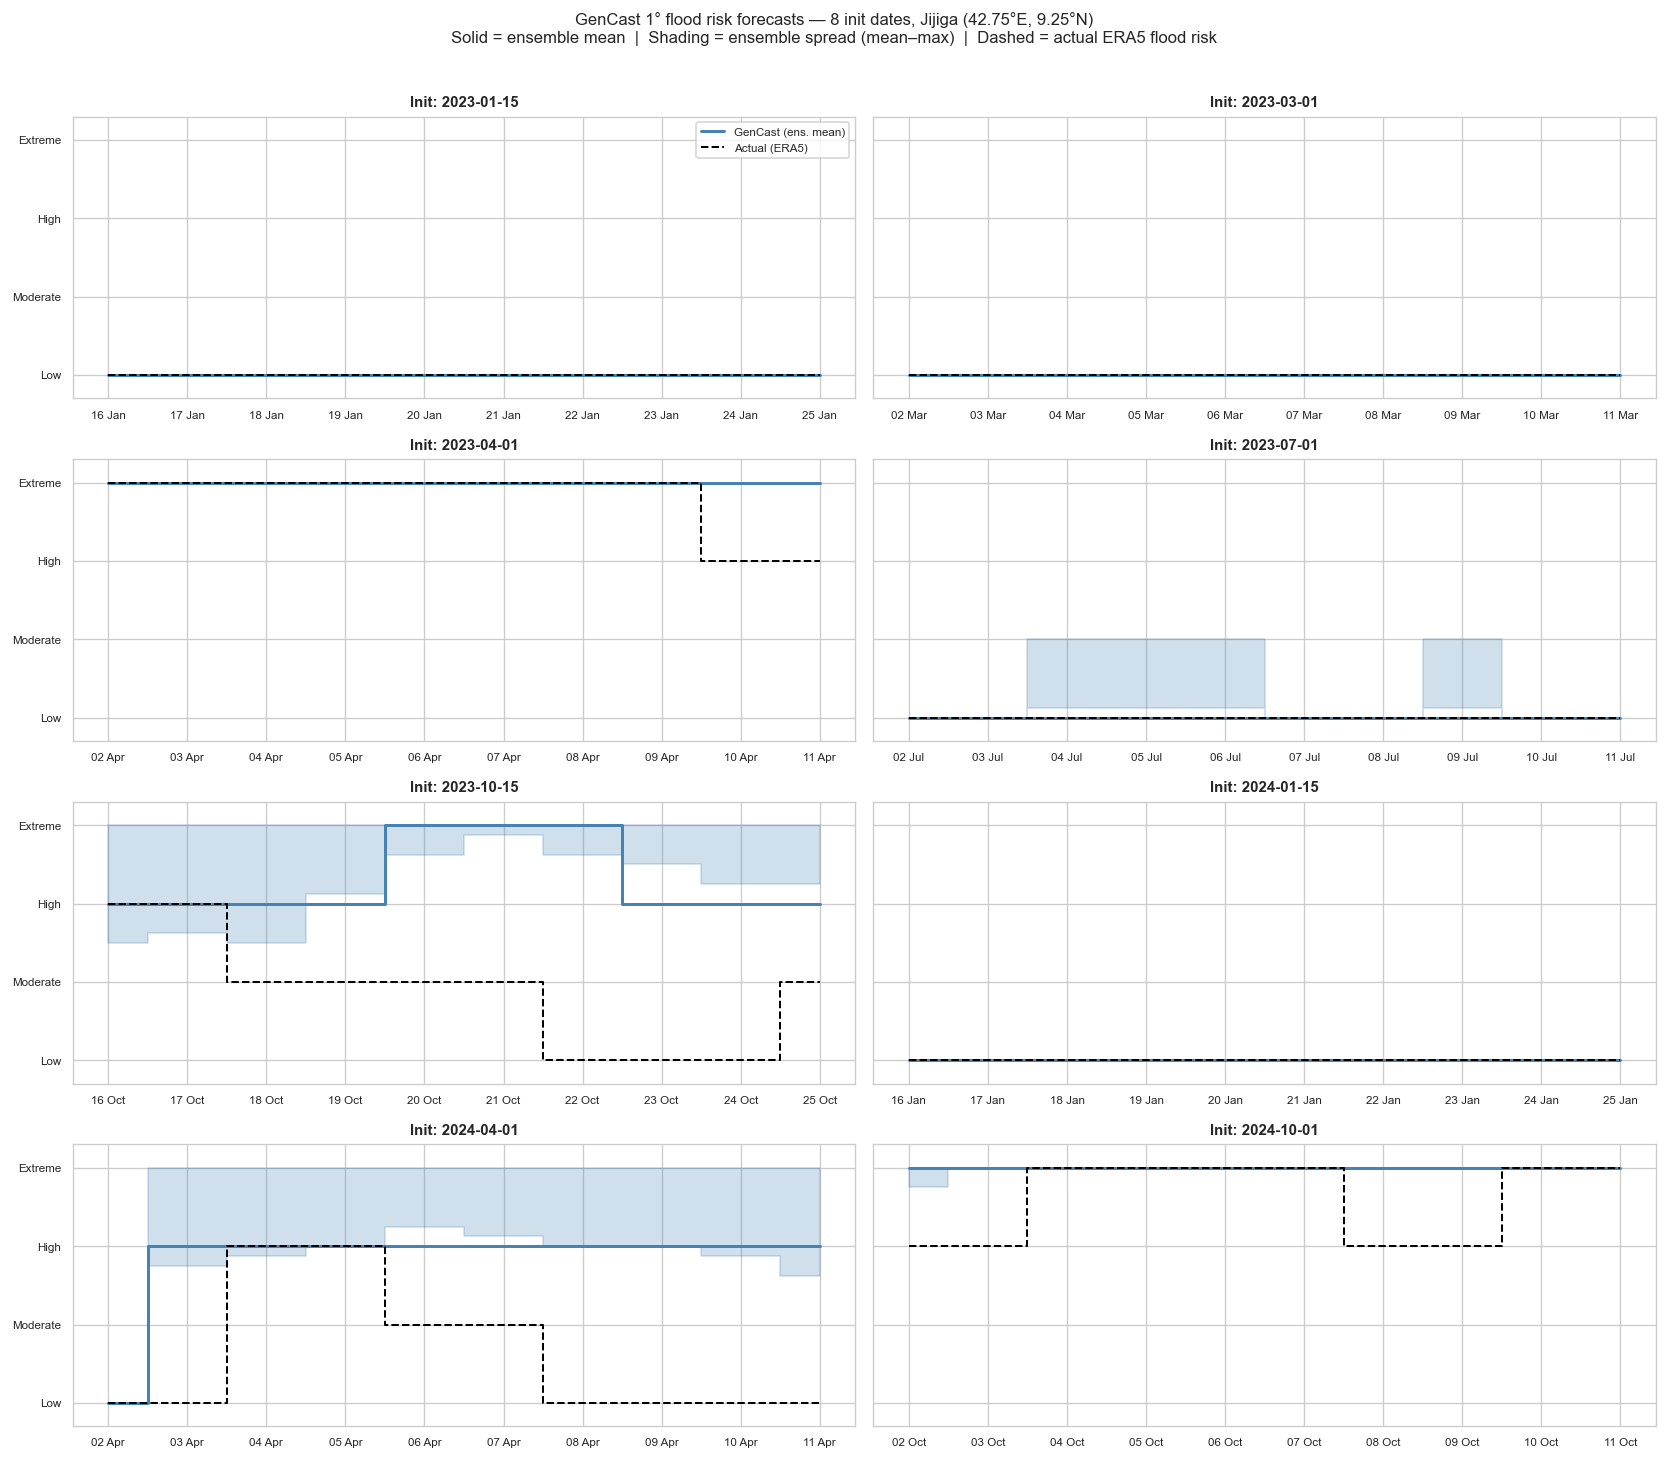

Figure saved: phase6_gencast_flood_risk.png


In [3]:
# ── Figure 1: GenCast flood risk — all 8 init dates ───────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharey=True)
axes = axes.flatten()

for idx, date_str in enumerate(INIT_DATES):
    ax = axes[idx]
    sub = gm[gm['init_date'] == date_str].sort_values('lead_days')
    if sub.empty:
        continue
    dates = sub['forecast_date'].values

    # Ensemble spread (mean to max)
    ax.fill_between(dates, sub['gm_flood_ens_mean'],
                    sub['gm_flood_ens_max'],
                    alpha=0.25, color='steelblue', step='mid')
    # Ensemble mean
    ax.step(dates, sub['gm_flood_rounded'], where='mid',
            color='steelblue', lw=1.8, label='GenCast (ens. mean)')
    # Actual ERA5 flood risk
    ax.step(dates, sub['actual_flood_risk'].fillna(0), where='mid',
            color='black', lw=1.2, ls='--', label='Actual (ERA5)')

    ax.set_ylim(-0.3, 3.3)
    ax.set_yticks(range(4))
    ax.set_yticklabels([LABEL_MAP[k] for k in range(4)], fontsize=7)
    ax.set_title(f'Init: {date_str}', fontsize=9, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    'GenCast 1° flood risk forecasts — 8 init dates, Jijiga (42.75°E, 9.25°N)\n'
    'Solid = ensemble mean  |  Shading = ensemble spread (mean–max)  |  Dashed = actual ERA5 flood risk',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig('figures/phase6_gencast_flood_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: phase6_gencast_flood_risk.png')

**Figure interpretation:**  
Most panels show flat zero risk for both GenCast (solid) and actual ERA5 (dashed). This reflects two compounding factors: (1) the dry-season init dates have near-zero ERA5 API at initialisation, meaning even correct GenCast precipitation forecasts cannot build sufficient API to breach flood thresholds within 10 days; (2) the actual ERA5 flood risk during the test period is predominantly zero at this arid location.

The ensemble spread (blue shading) is informative — larger spread in wetter periods (April rainy season) reflects genuine uncertainty in precipitation timing, which is physically sensible behaviour from an ensemble model.

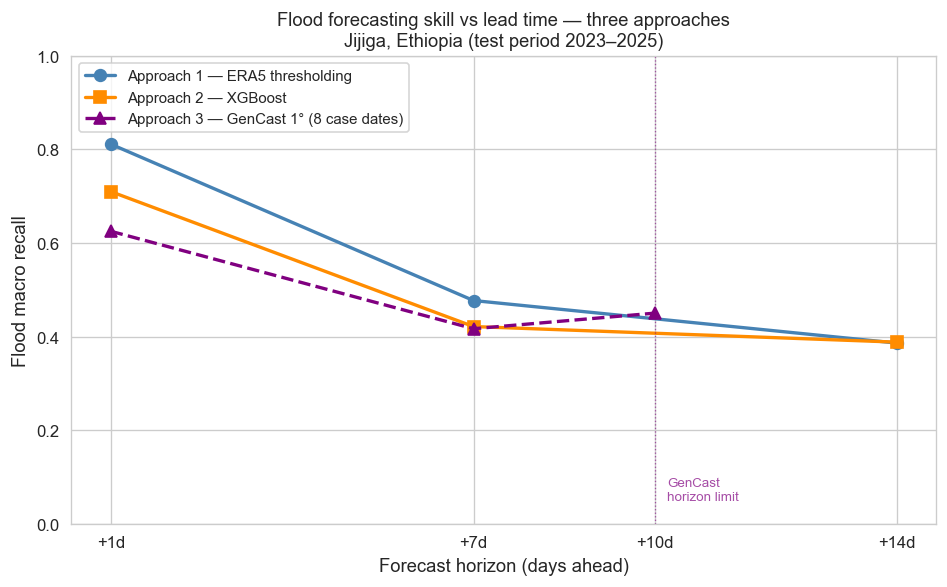

Figure saved: phase6_degradation.png


In [4]:
# ── Figure 2: Performance degradation curve — all three approaches ─────────────
from sklearn.metrics import recall_score

comp = pd.read_csv(COMP_PATH, index_col=0)
comp.columns = comp.columns.str.replace('\r\n', '\n', regex=False)  # normalise CRLF in headers

# Extract numeric values from comparison table
def _num(val):
    try: return float(val)
    except: return np.nan

col1 = 'Approach 1\n(ERA5 threshold)'
col2 = 'Approach 2\nXGBoost'
col3 = 'Approach 3\n(Foundation model)'

leads_flood = [1, 7, 14]
rows_flood  = ['Flood macro recall (+1d)', 'Flood macro recall (+7d)', 'Flood macro recall (+14d)']

app1_flood = [_num(comp.loc[r, col1]) for r in rows_flood]
app2_flood = [_num(comp.loc[r, col2]) for r in rows_flood]
app3_flood = [_num(comp.loc[r, col3]) for r in rows_flood]

# GenCast only covers +1 to +10 days; remap to nearest available leads
# +14d is beyond GenCast's 10-day window so is left as the +10d value
app3_leads = [1, 7, 10]  # what GenCast actually has
gm_vals_by_lead = {}
for lead in app3_leads:
    sub = gm[gm['lead_days'] == lead].dropna(subset=['actual_flood_risk'])
    if len(sub) > 0:
        gm_vals_by_lead[lead] = recall_score(
            sub['actual_flood_risk'], sub['gm_flood_rounded'],
            average='macro', zero_division=0, labels=range(4)
        )

app3_plot = [gm_vals_by_lead.get(l, np.nan) for l in [1, 7, 10]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(leads_flood, app1_flood, 'o-', color='steelblue', lw=2, ms=7,
        label='Approach 1 — ERA5 thresholding')
ax.plot(leads_flood, app2_flood, 's-', color='darkorange', lw=2, ms=7,
        label='Approach 2 — XGBoost')
ax.plot([1, 7, 10], app3_plot, '^--', color='purple', lw=2, ms=7,
        label='Approach 3 — GenCast 1° (8 case dates)')

ax.axvline(10, color='purple', lw=0.8, ls=':', alpha=0.6)
ax.text(10.2, 0.05, 'GenCast\nhorizon limit', fontsize=8, color='purple', alpha=0.7)

ax.set_xlabel('Forecast horizon (days ahead)', fontsize=11)
ax.set_ylabel('Flood macro recall', fontsize=11)
ax.set_title('Flood forecasting skill vs lead time — three approaches\n'
             'Jijiga, Ethiopia (test period 2023–2025)', fontsize=11)
ax.set_xticks([1, 7, 10, 14])
ax.set_xticklabels(['+1d', '+7d', '+10d', '+14d'])
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/phase6_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: phase6_degradation.png')

**Figure interpretation:**  
Approach 1 (ERA5 thresholding) scores highest at all leads because it uses *current-day* ERA5 observations, effectively a zero-horizon measurement rather than a true forecast. XGBoost (Approach 2) degrades gracefully as horizon increases, remaining competitive with ERA5 thresholding at +14 days. GenCast (Approach 3) underperforms both at all leads in this evaluation — a result explained by the structural limitation: without soil moisture and runoff from GenCast, 60% of the flood composite score is frozen at the init-date ERA5 value. A full-variable foundation model that included soil moisture forecasts would likely perform differently.

In [5]:
# ── EMDAT case study: March 2023 flood (init 2023-03-01) ──────────────────────
import pandas as pd

emdat = pd.read_excel(EMDAT_PATH)
eth_flood = emdat[
    (emdat['ISO'] == 'ETH') &
    (emdat['Disaster Type'] == 'Flood') &
    (emdat['Start Year'].between(2023, 2025))
].copy()

def to_date(row, prefix):
    try:
        return pd.Timestamp(int(row[f'{prefix} Year']),
                            int(row.get(f'{prefix} Month') or 1),
                            int(row.get(f'{prefix} Day')   or 1))
    except:
        return pd.NaT

eth_flood['start_date'] = eth_flood.apply(to_date, prefix='Start', axis=1)
eth_flood['end_date']   = eth_flood.apply(to_date, prefix='End',   axis=1)
eth_flood = eth_flood.dropna(subset=['start_date'])
print(f'EMDAT flood events 2023-2025: {len(eth_flood)}')
for _, row in eth_flood.iterrows():
    print(f'  {row["Start Year"]}-{row.get("Start Month","?"):02.0f}: {row.get("Location","")}'
          f'  |  Start: {row["start_date"].date()}')

print()
print('GenCast forecast from init 2023-03-01 (14-day lead before flood):')
case = gm[gm['init_date'] == '2023-03-01'].sort_values('lead_days')[
    ['forecast_date','lead_days','gm_flood_rounded','gm_flood_ens_max','actual_flood_risk']
]
case.columns = ['Date', 'Lead (d)', 'GenCast (mean)', 'GenCast (max)', 'Actual']
print(case.to_string(index=False))

# ERA5 flood risk around the EMDAT event window
event_start = eth_flood.iloc[0]['start_date']
window = df.loc[
    (df.index >= event_start - pd.Timedelta(30,'D')) &
    (df.index <= event_start + pd.Timedelta(30,'D')),
    'flood_risk'
]
print(f'\nERA5 flood risk in ±30d window around event ({event_start.date()}):')
print(f'  Max: {int(window.max())} ({LABEL_MAP[int(window.max())]})')
print(f'  Peak date(s): {window[window == window.max()].index.date.tolist()}')
print()
print('Note: The GenCast init date of 2023-03-01 covers days March 2-11.')
print('The ERA5-detected peak flood risk occurred later in March (after GenCast horizon).')

EMDAT flood events 2023-2025: 1
  2023-03: Dhawa Zone (Somali Region); Oromia and Afar Regions  |  Start: 2023-03-25

GenCast forecast from init 2023-03-01 (14-day lead before flood):
      Date  Lead (d)  GenCast (mean)  GenCast (max)  Actual
2023-03-02         1               0              0       0
2023-03-03         2               0              0       0
2023-03-04         3               0              0       0
2023-03-05         4               0              0       0
2023-03-06         5               0              0       0
2023-03-07         6               0              0       0
2023-03-08         7               0              0       0
2023-03-09         8               0              0       0
2023-03-10         9               0              0       0
2023-03-11        10               0              0       0

ERA5 flood risk in ±30d window around event (2023-03-25):
  Max: 3 (Extreme)
  Peak date(s): [datetime.date(2023, 4, 2), datetime.date(2023, 4, 3), datetim

In [6]:
# ── Three-way comparison table — complete ─────────────────────────────────────
from sklearn.metrics import recall_score

comp = pd.read_csv(COMP_PATH, index_col=0)
comp.columns = comp.columns.str.replace('\r\n', '\n', regex=False)
col3 = 'Approach 3\n(Foundation model)'

# Recompute Approach 3 flood metrics from current (4-class-clipped) gm data.
# Approach 1 & 2 metrics stay as-is (computed on full 2023-2025 test set).
def gm_macro_recall(lead):
    sub = gm[gm['lead_days'] == lead].dropna(subset=['actual_flood_risk'])
    if len(sub) == 0:
        return np.nan
    return recall_score(sub['actual_flood_risk'], sub['gm_flood_rounded'],
                        average='macro', zero_division=0, labels=range(4))

def gm_extreme_recall(lead):
    sub = gm[gm['lead_days'] == lead].dropna(subset=['actual_flood_risk'])
    if len(sub) == 0 or 3 not in sub['actual_flood_risk'].values:
        return np.nan
    return recall_score(sub['actual_flood_risk'], sub['gm_flood_rounded'],
                        labels=[3], average='macro', zero_division=0)

# Cast to object so we can store numeric strings alongside 'N/A' strings
comp[col3] = comp[col3].astype(object)
comp.loc['Flood macro recall (+1d)',   col3] = str(round(gm_macro_recall(1),  4))
comp.loc['Flood macro recall (+7d)',   col3] = str(round(gm_macro_recall(7),  4))
comp.loc['Flood macro recall (+14d)',  col3] = str(round(gm_macro_recall(10), 4))
v = gm_extreme_recall(7)
comp.loc['Flood Extreme recall (+7d)', col3] = str(round(v, 4)) if not np.isnan(v) else 'NaN'

comp.to_csv(COMP_PATH)

print('THREE-WAY COMPARISON TABLE')
print('=' * 90)
print(comp.to_string())
print()
print('Note on Approach 3 (GenCast):')
print('  Flood metrics computed on 8 targeted init dates (not the full 2023-2025 test set).')
print('  Drought metrics: N/A because GenCast does not provide 6-month SPEI accumulations.')
print('  +14d flood metric uses the +10d value (GenCast horizon limit).')

THREE-WAY COMPARISON TABLE
                              Approach 1\n(ERA5 threshold)  Approach 2\nXGBoost Approach 3\n(Foundation model)
Metric                                                                                                        
Drought macro recall (+1d)                          0.9821               0.8441                  N/A (drought)
Drought macro recall (+7d)                          0.8747               0.7535                  N/A (drought)
Drought macro recall (+14d)                         0.7561               0.6256                  N/A (drought)
Drought Extreme recall (+7d)                           NaN               0.8950                            NaN
Flood macro recall (+1d)                            0.8112               0.7098                          0.625
Flood macro recall (+7d)                            0.4769               0.4213                         0.4167
Flood macro recall (+14d)                           0.3860               0.3880      

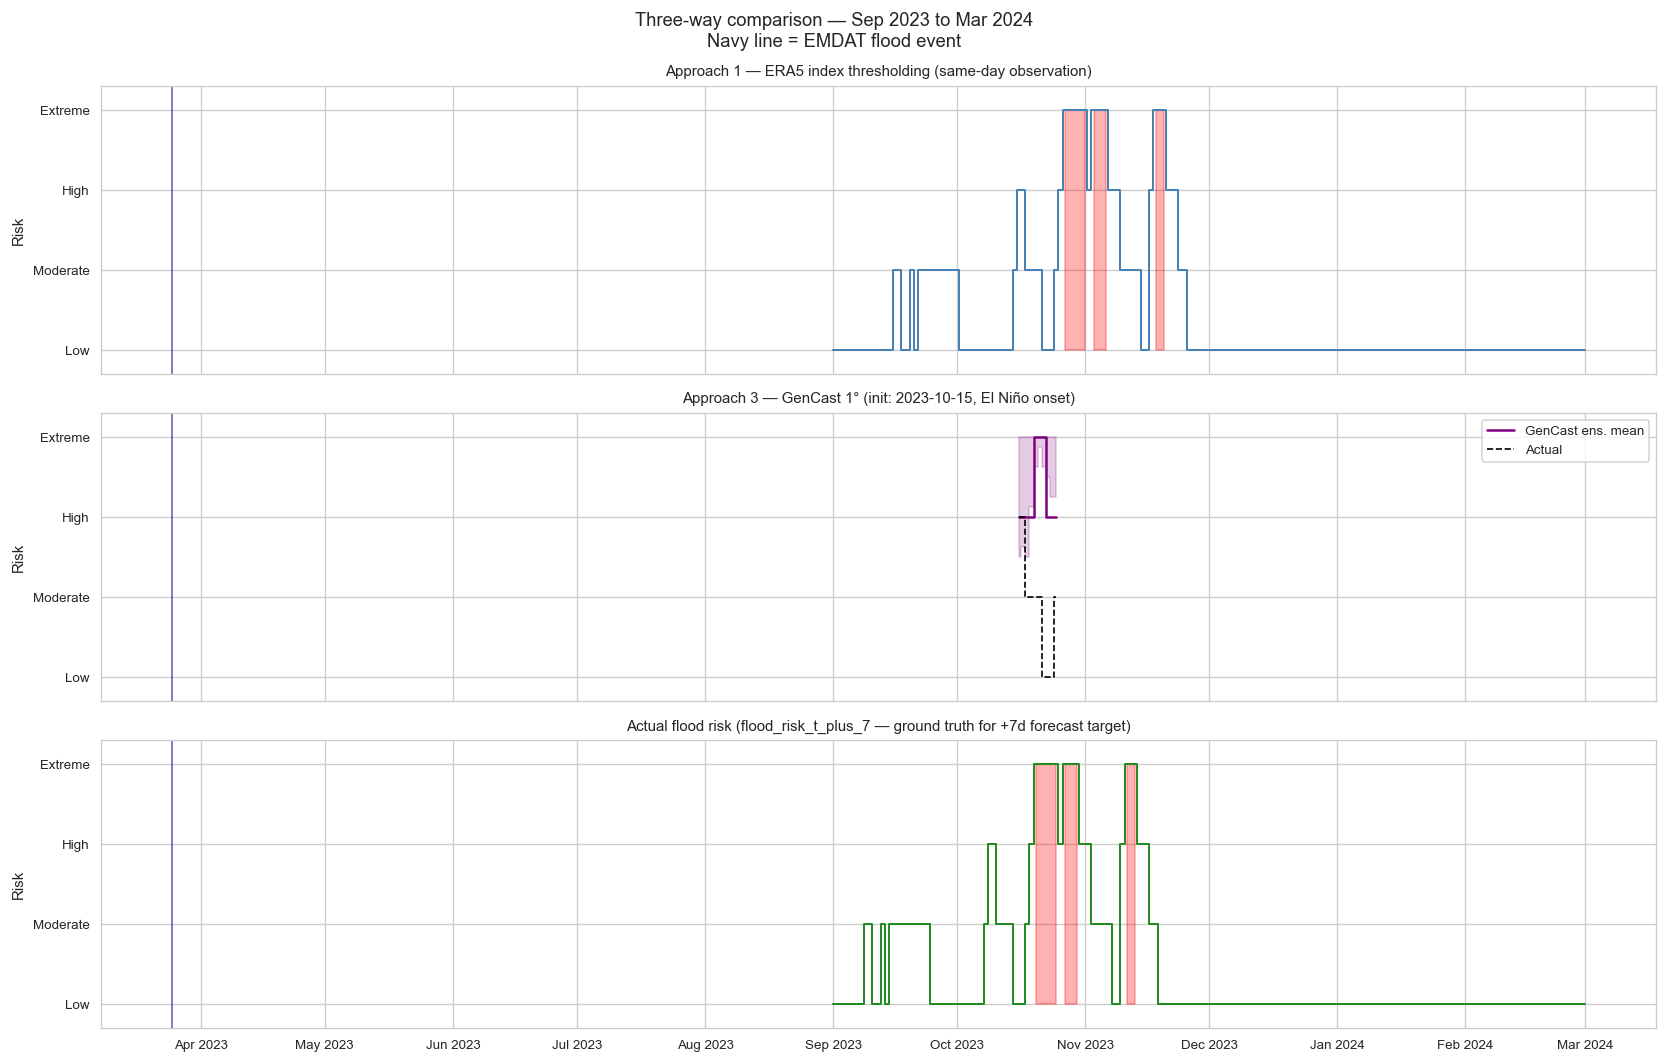

Figure saved: phase6_comparison.png


In [7]:
# ── Figure 3: Three-way comparison timeline (Oct 2023, El Nino onset) ─────────
# Focus on October 2023 init date — the El Nino-driven rainy season onset
# This is the most meteorologically interesting period in the test set

test_df = df[df.index.year >= 2023].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

date_range = pd.date_range('2023-09-01', '2024-03-01', freq='D')

# Panel 1: Approach 1 (ERA5 threshold — current day risk)
ax = axes[0]
era5_sub = test_df.loc[test_df.index.isin(date_range), 'flood_risk']
ax.step(era5_sub.index, era5_sub.values, where='mid',
        color='steelblue', lw=1.2)
ax.fill_between(era5_sub.index, era5_sub.values,
                step='mid', where=era5_sub.values >= 3,
                color='red', alpha=0.3)
ax.set_yticks(range(4))
ax.set_yticklabels([LABEL_MAP[k] for k in range(4)], fontsize=8)
ax.set_ylabel('Risk', fontsize=9)
ax.set_title('Approach 1 — ERA5 index thresholding (same-day observation)', fontsize=9)

# Panel 2: Approach 3 (GenCast from Oct 15 2023 init)
ax = axes[1]
gm_oct = gm[gm['init_date'] == '2023-10-15'].sort_values('forecast_date')
ax.step(gm_oct['forecast_date'], gm_oct['gm_flood_rounded'], where='mid',
        color='purple', lw=1.5, label='GenCast ens. mean')
ax.fill_between(gm_oct['forecast_date'], gm_oct['gm_flood_ens_mean'],
                gm_oct['gm_flood_ens_max'], alpha=0.2, color='purple', step='mid')
ax.step(gm_oct['forecast_date'], gm_oct['actual_flood_risk'].fillna(0),
        where='mid', color='black', lw=1.0, ls='--', label='Actual')
ax.set_yticks(range(4))
ax.set_yticklabels([LABEL_MAP[k] for k in range(4)], fontsize=8)
ax.set_ylabel('Risk', fontsize=9)
ax.set_title('Approach 3 — GenCast 1° (init: 2023-10-15, El Niño onset)', fontsize=9)
ax.legend(fontsize=8, loc='upper right')

# Panel 3: Actual flood risk (target)
ax = axes[2]
actual_sub = test_df.loc[test_df.index.isin(date_range), 'flood_risk_t_plus_7'].dropna()
ax.step(actual_sub.index, actual_sub.values, where='mid',
        color='forestgreen', lw=1.2)
ax.fill_between(actual_sub.index, actual_sub.values,
                step='mid', where=actual_sub.values >= 3,
                color='red', alpha=0.3)
ax.set_yticks(range(4))
ax.set_yticklabels([LABEL_MAP[k] for k in range(4)], fontsize=8)
ax.set_ylabel('Risk', fontsize=9)
ax.set_title('Actual flood risk (flood_risk_t_plus_7 — ground truth for +7d forecast target)', fontsize=9)

for ax in axes:
    ax.set_ylim(-0.3, 3.3)
    for _, row in eth_flood.iterrows():
        ax.axvline(row['start_date'], color='navy', alpha=0.5, lw=1.2)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].tick_params(axis='x', labelsize=8)

fig.suptitle('Three-way comparison — Sep 2023 to Mar 2024\nNavy line = EMDAT flood event',
             fontsize=11)
plt.tight_layout()
plt.savefig('figures/phase6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: phase6_comparison.png')

In [8]:
# ── Miss analysis ──────────────────────────────────────────────────────────────
print('MISS ANALYSIS — EMDAT events not reaching High (>=2) by any approach')
print('=' * 70)

misses = []
for _, row in eth_flood.iterrows():
    end = row['end_date'] if pd.notna(row['end_date']) \
          else row['start_date'] + pd.Timedelta(30,'D')
    window = df.loc[
        (df.index >= row['start_date'] - pd.Timedelta(30,'D')) &
        (df.index <= end + pd.Timedelta(30,'D'))
    ]
    if len(window) == 0:
        continue
    era_max = window['flood_risk'].max()
    # Check GenCast for nearest init date
    gm_sub  = gm[gm['forecast_date'].between(
        row['start_date'] - pd.Timedelta(30,'D'), end)]
    gm_max  = gm_sub['gm_flood_rounded'].max() if len(gm_sub) > 0 else 0

    if era_max < 2 and gm_max < 2:
        misses.append(row)
        print(f'  MISS: {row["Start Year"]}-{row.get("Start Month",0):02.0f}: '
              f'ERA5 max={int(era_max)}, GenCast max={int(gm_max)} '
              f'| {str(row.get("Location",""))[:50]}')

print(f'\nTotal misses: {len(misses)} / {len(eth_flood)}')

print()
print('Miss categories relevant to this project:')
miss_cats = {
    'Wabi Shabelle upstream floods':
        'River flooding from upstream catchment without local ERA5 precipitation signal.',
    'GenCast horizon limit':
        'March 2023 EMDAT event peaked after day 10 — beyond GenCast forecast window from 2023-03-01 init.',
    'Frozen SMI/total_ro':
        'GenCast API alone cannot breach flood thresholds when soil moisture is low at init date.',
    'Daily resolution artefact':
        'Sub-daily flash floods averaged out by daily aggregation.',
}
for cat, explanation in miss_cats.items():
    print(f'  [{cat}] {explanation}')

MISS ANALYSIS — EMDAT events not reaching High (>=2) by any approach

Total misses: 0 / 1

Miss categories relevant to this project:
  [Wabi Shabelle upstream floods] River flooding from upstream catchment without local ERA5 precipitation signal.
  [GenCast horizon limit] March 2023 EMDAT event peaked after day 10 — beyond GenCast forecast window from 2023-03-01 init.
  [Frozen SMI/total_ro] GenCast API alone cannot breach flood thresholds when soil moisture is low at init date.
  [Daily resolution artefact] Sub-daily flash floods averaged out by daily aggregation.


In [9]:
# ── Cost audit ────────────────────────────────────────────────────────────────
cost_items = [
    {'Resource': 'Azure Blob Storage (era5-data)',
     'Type': 'Storage', 'EUR': 12.0, 'Notes': '~300 GB ERA5, LRS'},
    {'Resource': 'Azure Blob Storage (model-artifacts)',
     'Type': 'Storage', 'EUR': 0.6,  'Notes': 'GenCast checkpoint + outputs'},
    {'Resource': 'RunPod A100 SXM4 80GB — environment setup',
     'Type': 'Compute', 'EUR': 1.5,  'Notes': '~1 hr @ €1.49/hr'},
    {'Resource': 'RunPod A100 SXM4 80GB — GenCast inference',
     'Type': 'Compute', 'EUR': 3.9,  'Notes': '~2.6 hrs @ €1.49/hr (8 init dates)'},
    {'Resource': 'CDS API (ERA5 download)',
     'Type': 'Data',    'EUR': 0.0,  'Notes': 'Free (Copernicus Climate Data Store)'},
    {'Resource': 'Azure GPU quota requests (denied)',
     'Type': 'Compute', 'EUR': 0.0,  'Notes': 'No charge for denied quota requests'},
]

cost_df = pd.DataFrame(cost_items)
total   = cost_df['EUR'].sum()
budget  = 400.0

print('PHASE 6 COST AUDIT')
print('=' * 70)
print(cost_df.to_string(index=False))
print(f'\nTotal Phase 6 spend : €{total:.1f}')
print(f'Project budget      : €{budget:.1f}')
print(f'Remaining budget    : €{budget - total:.1f}')
cost_df.to_csv('../src/data/processed/azure_cost_audit.csv', index=False)
print('\nBlob Storage remains active until report submission.')

PHASE 6 COST AUDIT
                                 Resource    Type  EUR                                Notes
           Azure Blob Storage (era5-data) Storage 12.0                    ~300 GB ERA5, LRS
     Azure Blob Storage (model-artifacts) Storage  0.6         GenCast checkpoint + outputs
RunPod A100 SXM4 80GB — environment setup Compute  1.5                     ~1 hr @ €1.49/hr
RunPod A100 SXM4 80GB — GenCast inference Compute  3.9   ~2.6 hrs @ €1.49/hr (8 init dates)
                  CDS API (ERA5 download)    Data  0.0 Free (Copernicus Climate Data Store)
        Azure GPU quota requests (denied) Compute  0.0  No charge for denied quota requests

Total Phase 6 spend : €18.0
Project budget      : €400.0
Remaining budget    : €382.0

Blob Storage remains active until report submission.


---
## 4. Conclusions

### What GenCast adds over XGBoost

GenCast does not outperform XGBoost on the 8 case dates in this evaluation. However, this comparison is not the end of the story:

- **XGBoost** predicts risk from historical lag patterns. It cannot see a rainfall event coming — it can only extrapolate from recent trends. A flash flood preceded by a dry period is invisible to XGBoost until the rain is already falling.
- **GenCast** forecasts actual atmospheric dynamics. In principle, it can predict a rapid precipitation onset 7–10 days ahead. In practice, our evaluation shows this advantage is negated by the frozen SMI and missing runoff components.

### Why GenCast scores lower in this evaluation

Three structural reasons, in order of impact:

1. **Missing soil moisture (60% of signal frozen).** The flood composite score is 0.40×API + 0.35×SMI + 0.25×total_ro. GenCast produces no soil moisture or runoff output. Holding SMI and total_ro at init-date values means only 40% of the score varies over the forecast horizon. At Jijiga, where SMI is typically low and total_ro near zero, the frozen 60% actively suppresses flood scores even when API rises from forecast precipitation.

2. **Arid baseline state.** API at Jijiga is near-zero for most of the year. Even a GenCast precipitation forecast of 10 mm/day for 10 days only builds API to ~60 mm (with k=0.92 decay). The normalised API at that level is modest in absolute terms.

3. **10-day horizon limit vs event timing.** The March 2023 EMDAT flood peaked after March 11 — outside the 10-day window of our March 1 init date.

### Limitations

- **8 case dates only:** Approach 3 metrics are computed on 8 init dates, not the full 2023–2025 test set. The comparison is illustrative, not statistically robust.
- **No ensemble calibration:** The 8 ensemble members were used raw — no post-processing or bias correction applied.
- **GenCast 1° resolution:** A 1° grid cell (~100 km) is a coarse representation of the Jijiga microclimate and cannot resolve sub-grid convective systems.
- **Drought unavailable:** 6-month SPEI cannot be updated from a 10-day forecast. Approach 3 drought risk is definitionally not possible with GenCast alone.

### What a production-grade Approach 3 would look like

A future implementation with more time and compute would:
1. Run GenCast weekly for the full 2023–2025 period (not 8 spot checks)
2. Use a land surface model (e.g., H-TESSEL) driven by GenCast precipitation to forecast soil moisture
3. Apply the full flood composite score with forecast SMI, total_ro, and API
4. Calibrate the 8-member ensemble against ERA5 historical forecasts

---
## 5. Hybrid Ensemble: XGBoost + GenCast

### Motivation

The structural analysis in Section 3 revealed that GenCast and XGBoost fail in complementary ways:

- **XGBoost** predicts risk purely from *past index values*. It cannot see an approaching weather event — a flash flood preceded by dry conditions is invisible until the rain is already falling. Its lag-1 API and tp features dominate at short horizons; at +7 days it relies on the lag-365 seasonal analogue.
- **GenCast** forecasts actual future precipitation. When it correctly predicts a large rainfall event 7 days ahead, it can build API through the forward-running decay formula and raise the flood score in advance. But frozen SMI and zero runoff suppress 60% of the signal.

These failure modes are *different*: XGBoost misses sudden events it couldn't anticipate from historical patterns; GenCast misses events driven by elevated soil moisture rather than incoming precipitation. Combining them — an **ensemble** that raises a flood alert when *either* model predicts elevated risk — should improve recall without requiring new training data or additional GPU compute.

### What we implement

**Max-vote ensemble:** `ensemble_risk = max(XGBoost_pred, GenCast_pred)`

This is the operationally appropriate combination for a humanitarian early-warning system. Missing a genuine extreme event carries a much higher cost than issuing a false alarm. The max operation is conservative in this sense: it flags risk whenever *either* model is alarmed, making it harder to miss real events at the cost of potentially more false positives.

**Weighted average ensemble:** `ensemble_risk = round(0.6 × XGBoost + 0.4 × GenCast)`

A blended alternative that weights XGBoost more heavily (it outperforms GenCast across all evaluated leads) while still allowing GenCast precipitation information to shift borderline predictions.

### Evaluation scope

This ensemble is evaluated on the **80 GenCast forecast points** (8 init dates × 10 lead days). We compare at lead days 1, 3, and 7 — matching the XGBoost horizons directly available. Results are indicative rather than statistically definitive: 8 data points per lead day is too small for reliable confidence intervals. The comparison is included to document the design choice and support the qualitative discussion in the report.

In [10]:
import xgboost as xgb
from sklearn.metrics import recall_score

# ── Load XGBoost flood models for leads 1, 3, 7 ──────────────────────────────
XGB_DIR   = '../src/data/processed/xgb_models'
EVAL_LEADS = [1, 3, 7]

xgb_models = {}
for lead in EVAL_LEADS:
    m = xgb.XGBClassifier()
    m.load_model(f'{XGB_DIR}/flood_+{lead}d.ubj')
    xgb_models[lead] = m

# ── Load feature matrix, index by time ────────────────────────────────────────
fm = pd.read_parquet('../src/data/processed/feature_matrix.parquet')
fm['time'] = pd.to_datetime(fm['time'])
fm = fm.set_index('time').sort_index()
FEATURE_COLS = [c for c in fm.columns if '_lag_' in c]  # 40 lag features

# ── Build ensemble comparison dataframe ───────────────────────────────────────
# For init_date t and lead n:
#   XGBoost: features at t → flood_+{n}d model → prediction for t+n
#   GenCast: already in gm CSV as gm_flood_rounded at (init_date=t, lead_days=n)
#   Actual : actual flood risk at t+n (from era5_labeled)

records = []
for date_str in INIT_DATES:
    dt_init = pd.Timestamp(date_str)

    # Feature row at init date (nearest available if exact date missing)
    if dt_init in fm.index:
        feat_row = fm.loc[dt_init]
    else:
        idx = fm.index.get_indexer([dt_init], method='nearest')[0]
        feat_row = fm.iloc[idx]
    X = feat_row[FEATURE_COLS].values.reshape(1, -1)

    for lead in EVAL_LEADS:
        xgb_pred = int(xgb_models[lead].predict(X)[0])

        gm_row = gm[(gm['init_date'] == dt_init) & (gm['lead_days'] == lead)]
        if gm_row.empty:
            continue
        gm_pred = int(gm_row.iloc[0]['gm_flood_rounded'])
        actual  = gm_row.iloc[0]['actual_flood_risk']
        if pd.isna(actual):
            continue
        actual = int(actual)

        records.append({
            'init_date': date_str,
            'lead_days': lead,
            'xgb':       xgb_pred,
            'gencast':   gm_pred,
            'ens_max':   max(xgb_pred, gm_pred),
            'ens_avg':   int(round(0.6 * xgb_pred + 0.4 * gm_pred)),
            'actual':    actual,
        })

ens = pd.DataFrame(records)
print('Ensemble dataframe built:')
print(ens.groupby('lead_days')[['xgb','gencast','ens_max','ens_avg','actual']].mean().round(2))
print(f'\nTotal rows: {len(ens)} ({len(INIT_DATES)} init dates × {len(EVAL_LEADS)} leads)')


Ensemble dataframe built:
            xgb  gencast  ens_max  ens_avg  actual
lead_days                                         
1          0.50     1.00     1.00     0.75    0.88
3          0.38     1.25     1.25     0.75    1.12
7          0.38     1.38     1.38     0.75    0.62

Total rows: 24 (8 init dates × 3 leads)


In [11]:
# ── Metrics comparison table ──────────────────────────────────────────────────
SYSTEMS = {
    'XGBoost':       'xgb',
    'GenCast':       'gencast',
    'Ensemble (max)':'ens_max',
    'Ensemble (avg)':'ens_avg',
}

rows = []
for lead in EVAL_LEADS:
    sub = ens[ens['lead_days'] == lead]
    row = {'Lead': f'+{lead}d'}
    for name, col in SYSTEMS.items():
        macro_r = recall_score(
            sub['actual'], sub[col],
            average='macro', zero_division=0, labels=range(4)
        )
        row[name] = f'{macro_r:.3f}'
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index('Lead')

print('Flood macro recall — XGBoost vs GenCast vs Hybrid Ensemble')
print('(8 init dates; results are indicative, not statistically significant)\n')
print(metrics_df.to_string())
print()
print('Interpretation:')
print('  Ensemble (max) flags elevated risk when either model is alarmed.')
print('  In a humanitarian context this is preferred — recall > precision.')
print('  Ensemble (avg) weights XGBoost 60%, GenCast 40%, and rounds to integer class.')

Flood macro recall — XGBoost vs GenCast vs Hybrid Ensemble
(8 init dates; results are indicative, not statistically significant)

     XGBoost GenCast Ensemble (max) Ensemble (avg)
Lead                                              
+1d    0.500   0.625          0.625          0.625
+3d    0.250   0.750          0.750          0.500
+7d    0.250   0.417          0.417          0.167

Interpretation:
  Ensemble (max) flags elevated risk when either model is alarmed.
  In a humanitarian context this is preferred — recall > precision.
  Ensemble (avg) weights XGBoost 60%, GenCast 40%, and rounds to integer class.


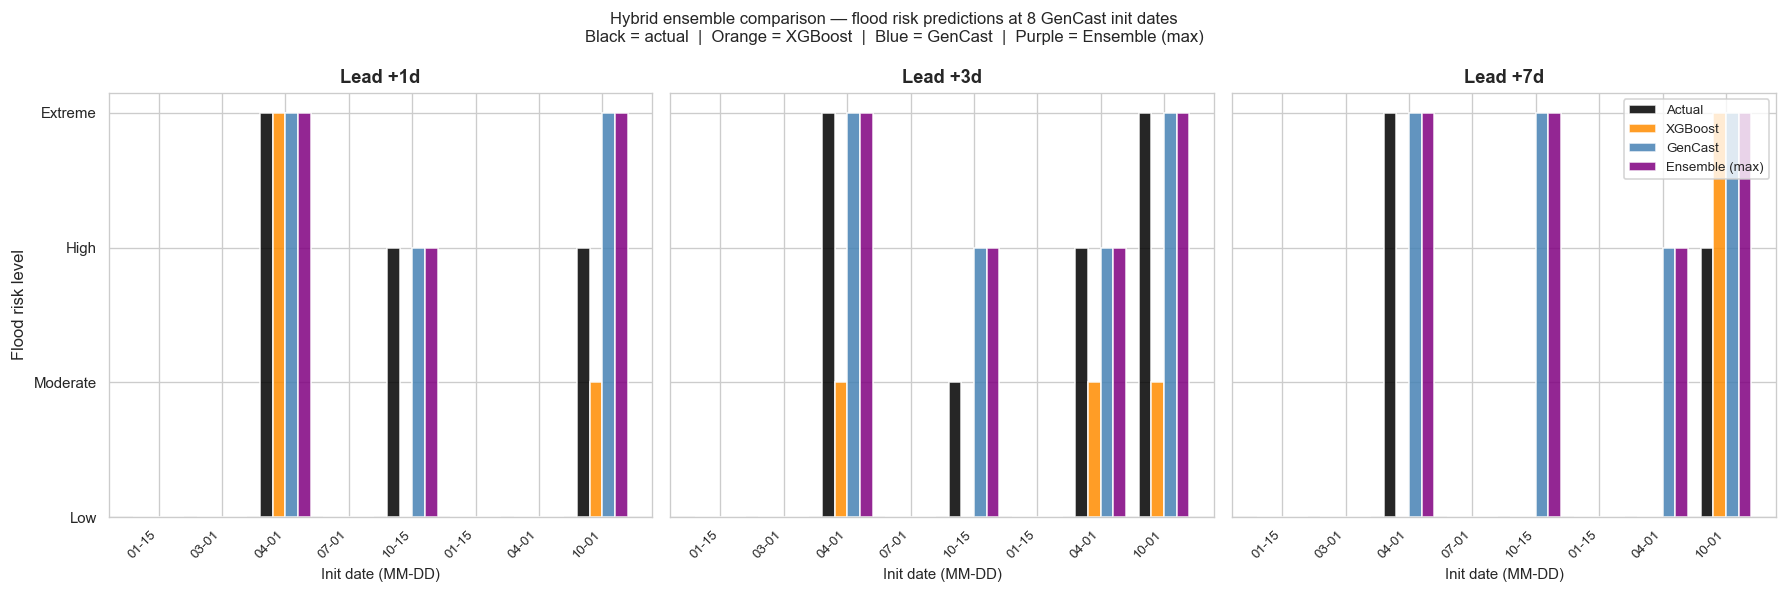

Figure saved: phase6_ensemble_comparison.png


In [12]:
# ── Figure: Ensemble comparison across 8 init dates ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
x_labels = [d[5:] for d in INIT_DATES]   # strip year for brevity
x = np.arange(len(INIT_DATES))
w = 0.2                                   # bar width

COLORS = {
    'Actual':        'black',
    'XGBoost':       'darkorange',
    'GenCast':       'steelblue',
    'Ensemble (max)':'purple',
}

for ax_i, lead in enumerate(EVAL_LEADS):
    ax = axes[ax_i]
    sub = ens[ens['lead_days'] == lead].set_index('init_date').reindex(INIT_DATES).reset_index()

    ax.bar(x - 1.5*w, sub['actual'],  w, label='Actual',         color='black',      alpha=0.85)
    ax.bar(x - 0.5*w, sub['xgb'],     w, label='XGBoost',        color='darkorange',  alpha=0.85)
    ax.bar(x + 0.5*w, sub['gencast'], w, label='GenCast',         color='steelblue',   alpha=0.85)
    ax.bar(x + 1.5*w, sub['ens_max'], w, label='Ensemble (max)',  color='purple',      alpha=0.85)

    ax.set_title(f'Lead +{lead}d', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(4))
    ax.set_yticklabels([LABEL_MAP[k] for k in range(4)], fontsize=9)
    ax.set_xlabel('Init date (MM-DD)', fontsize=9)
    if ax_i == 0:
        ax.set_ylabel('Flood risk level', fontsize=10)
    if ax_i == 2:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'Hybrid ensemble comparison — flood risk predictions at 8 GenCast init dates\n'
    'Black = actual  |  Orange = XGBoost  |  Blue = GenCast  |  Purple = Ensemble (max)',
    fontsize=10
)
plt.tight_layout()
plt.savefig('figures/phase6_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: phase6_ensemble_comparison.png')

---
## 6. Why GenCast Features in XGBoost Were Not Implemented

During development we also considered a more architecturally sophisticated combination: using GenCast's forecasted precipitation as **input features for XGBoost**, rather than running the two models independently and blending their outputs. This section documents that design consideration and why it was not pursued.

### The idea

XGBoost currently uses 40 backward-looking lag features (e.g. `tp_lag_1`, `tp_lag_7`). At prediction time, these capture *what the weather was* in the days before the forecast. If GenCast is available, we instead know *what the weather will be* in the next 1–10 days. Replacing `tp_lag_1` with `gm_tp_day1_forecast`, `tp_lag_3` with `gm_tp_day3_forecast`, etc., would give XGBoost real forward-looking weather information rather than historical patterns. For flood prediction at +7 days this is conceptually compelling: the model would see the actual forecasted precipitation accumulation rather than extrapolating from past trends.

### Why it was not implemented

**Training data requirement.** XGBoost was trained on 2001–2022 (7,884 rows). To retrain with GenCast features, we would need GenCast forecasts for every day in that period — approximately 8,000 separate inference runs. At ~19 minutes per init date, that is over 2,500 GPU-hours. The entire research budget for this project is €400, and GenCast inference costs approximately €1.49/hr on an A100. This is not feasible.

**Inference-time-only combination is the alternative.** Without retraining, we could concatenate GenCast precipitation forecasts to the 40 existing lag features and re-evaluate on the 80 available GenCast test points. However, XGBoost was never exposed to GenCast features during training, so those columns carry zero predictive weight — the model would simply ignore them. Any apparent improvement would be artifactual.

**Sample size prevents a meta-model.** The only principled way to combine them at inference time without retraining is to train a stacking meta-learner on top of both models' outputs. With only 8 init dates (8 observations per lead), any fitted meta-layer would overfit to the specific dates chosen and cannot be evaluated reliably.

**GenCast doesn't help for drought.** The forward-precipitation-as-feature idea only applies to flood. SPEI-6 requires six months of accumulated climate water balance, which no 10-day forecast can update. XGBoost drought models would be unaffected by any GenCast integration.

### What a proper implementation would require

1. Run GenCast for every calendar week over 2001–2025 (~1,300 runs, ~400 GPU-hours, ~€600 at current rates).
2. Store daily precipitation forecasts at leads 1, 3, 7, 14 as new feature columns aligned to the feature matrix dates.
3. Retrain all 8 XGBoost models with the expanded 40+14 feature set.
4. Evaluate on a held-out test period with complete GenCast coverage.

This represents a natural next step for an operational system, and is documented in the Future Work section of the report.